In [1]:
import sys

#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent))
import config
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, BaseCrossValidator
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from src.cleaning import clean
from src.feature_engineering import build_panel_data
import joblib
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)


train = panel_data[panel_data['Year'] <= 2022]
# calibrate = panel_data[panel_data['Year'] == 2023]
test = panel_data[panel_data['Year'] == 2024]
train_X = train[config.FEATURES]
train_y = train['Churns']
# calibrate_X = calibrate[config.FEATURES]
# calibrate_y = calibrate['Churns']
test_X = test[config.FEATURES]
test_y = test['Churns']

calibrated_clf = joblib.load('calibrated_model.pkl')

probs = calibrated_clf.predict_proba(test_X)[:, 1]
preds = calibrated_clf.predict(test_X)

C:\Users\bnpar\AppData\Local\Temp\ipykernel_39792\4131147749.py:24: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


Given the model is intended to be used to target retention interventions, the most important metrics of the model are:

- **Expected profit**
- The **calibration of the model, evaluated on the test set**. For the expected profit to be accurate i) the calibration needs to be accurate ii) the save rate needs to be accurate. Therefore model calibration is essential. This can be seen in `notebooks/06_calibration.ipynb` 

Other evaluation metrics are secondary to these, but are also included in this notebook.

### Profit on test set

`notebooks/07_calibration.ipynb` uses the model probabilities to calculate expected profit uplift on 2024 data (the test set). In this notebook we use actual outcomes from test set to look at what the profit uplift would have been, still assuming a save rate of 15%.

Total lifters in target band: 13,943
Control group (withheld): 1,370
Treatment group (intervened): 12,573

Revenue from successful interventions (true positives retained): £53,130
Cost of false positives (non-churners unnecessarily offered discount): £37,180
Net uplift from treatment group: £15,950


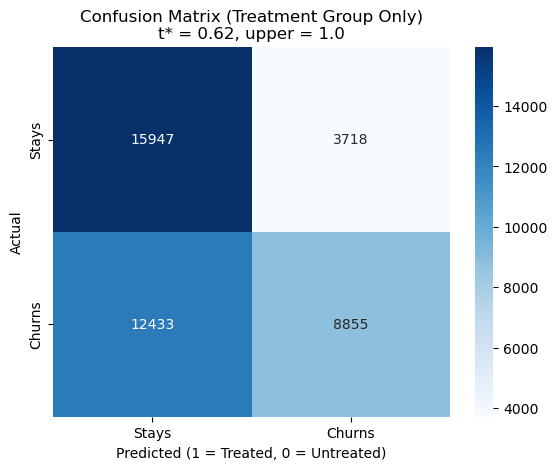

In [10]:
# Parameters
t_star = 0.62
upper_threshold = 1.0
save_rate = 0.15
V = 50
C = 10
n_control = 1370

# 1. Identify the full target band
in_window = (probs > t_star) & (probs <= upper_threshold)
target_indices = np.where(in_window)[0]

# 2. Randomly split into treatment and control
rng = np.random.default_rng(42)
control_indices = rng.choice(target_indices, size=n_control, replace=False)
treatment_indices = np.setdiff1d(target_indices, control_indices)

# 3. Create prediction array ONLY for the treated group
preds_treatment = np.zeros_like(probs, dtype=int)
preds_treatment[treatment_indices] = 1

# 4. Generate Confusion Matrix
cm = confusion_matrix(test_y, preds_treatment)
tn, fp, fn, tp = cm.ravel()

# 5. Financial Calculations
est_from_intervention = tp * save_rate * (V - C)
est_wasted = fp * C
lost_fn = fn * (V - C) * save_rate # Note: FN now includes missed targets AND the control group
net_uplift = est_from_intervention - est_wasted

# Outputs
print(f'Total lifters in target band: {len(target_indices):,}')
print(f'Control group (withheld): {n_control:,}')
print(f'Treatment group (intervened): {len(treatment_indices):,}\n')

print(f'Revenue from successful interventions (true positives retained): £{est_from_intervention:,.0f}')
print(f'Cost of false positives (non-churners unnecessarily offered discount): £{est_wasted:,.0f}')
print(f'Net uplift from treatment group: £{net_uplift:,.0f}')

# Plotting
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted (1 = Treated, 0 = Untreated)')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Treatment Group Only)\nt* = {t_star}, upper = {upper_threshold}')
plt.show()

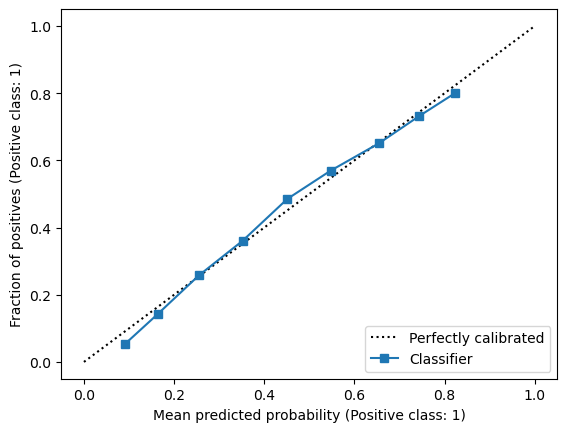

In [5]:
CalibrationDisplay.from_predictions(test_y, probs, n_bins=10)
plt.show()


### Note on other evaluation metrics

Note that $t^*$ was chosen to maximise expected profit. As a result, precision, recall etc. may differ from a threshold tuned for classification performance, and should be interpreted as descriptive rather than as measures of model quality.

In [13]:
preds = (probs >= t_star).astype(int)

scores_dict = {
    "f1":        f1_score(test_y, preds),
    "recall":    recall_score(test_y, preds),
    "accuracy":  accuracy_score(test_y, preds),
    "precision": precision_score(test_y, preds),
}
print(scores_dict)



{'f1': 0.5559876245352104, 'recall': 0.46007140172867345, 'accuracy': 0.618025541474373, 'precision': 0.7024313275478735}
The classifier has an accuracy of 61.80%
The model gives a 9.82% improvement in accuracy compared to a majority class baseline of 51.98%.
